In [2]:
import numpy as np

import pywt
import cv2
import os
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

# For display (optional)
import matplotlib.pyplot as plt


In [18]:
BSD68_DIR = "./data/BSD68/"
CLEAN_DIR = os.path.join(BSD68_DIR, "original_png")
NOISY_DIR = os.path.join(BSD68_DIR, "noisy25")

def load_images(folder):
    imgs = []
    fnames = sorted(os.listdir(folder))
    for fname in fnames:
        path = os.path.join(folder, fname)
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = img.astype(np.float32) / 255.0
        imgs.append(img)
    return imgs, fnames

clean_imgs, clean_names = load_images(CLEAN_DIR)
noisy_imgs, noisy_names = load_images(NOISY_DIR)

print("Loaded clean images:", len(clean_imgs))
print("Loaded noisy25 images:", len(noisy_imgs))
#print(clean_names)
#print(noisy_names)

Loaded clean images: 68
Loaded noisy25 images: 68
['0000.png', '0001.png', '0002.png', '0003.png', '0004.png', '0005.png', '0006.png', '0007.png', '0008.png', '0009.png', '0010.png', '0011.png', '0012.png', '0013.png', '0014.png', '0015.png', '0016.png', '0017.png', '0018.png', '0019.png', '0020.png', '0021.png', '0022.png', '0023.png', '0024.png', '0025.png', '0026.png', '0027.png', '0028.png', '0029.png', '0030.png', '0031.png', '0032.png', '0033.png', '0034.png', '0035.png', '0036.png', '0037.png', '0038.png', '0039.png', '0040.png', '0041.png', '0042.png', '0043.png', '0044.png', '0045.png', '0046.png', '0047.png', '0048.png', '0049.png', '0050.png', '0051.png', '0052.png', '0053.png', '0054.png', '0055.png', '0056.png', '0057.png', '0058.png', '0059.png', '0060.png', '0061.png', '0062.png', '0063.png', '0064.png', '0065.png', '0066.png', '0067.png']
['0000.png', '0001.png', '0002.png', '0003.png', '0004.png', '0005.png', '0006.png', '0007.png', '0008.png', '0009.png', '0010.png', 

In [19]:
def soft_threshold(x, lam):
    return np.sign(x) * np.maximum(np.abs(x) - lam, 0)
def wavelet_denoise_once(noisy, wavelet_name, sigma):
    # 小波分解
    coeffs = pywt.wavedec2(noisy, wavelet=wavelet_name, level=3)

    # universal threshold
    N = noisy.size
    lam = (sigma / 255.0) * np.sqrt(2 * np.log(N))

    new_coeffs = []
    for c in coeffs:
        if isinstance(c, tuple):  # detail bands
            new_coeffs.append(
                tuple(soft_threshold(sub, lam) for sub in c)
            )
        else:
            new_coeffs.append(c)  # approximation unchanged

    # 重建图像
    den = pywt.waverec2(new_coeffs, wavelet=wavelet_name)
    return np.clip(den, 0, 1)


In [20]:
wavelets = ["db2", "db4", "sym8"]

def multi_wavelet_pocs(noisy, sigma, wavelets, iters=6):
    x = noisy.copy()
    for _ in range(iters):
        for w in wavelets:
            x = wavelet_denoise_once(x, w, sigma)
    return x


In [21]:
def evaluate(clean, denoised):
    psnr = peak_signal_noise_ratio(clean, denoised, data_range=1.0)
    ssim = structural_similarity(clean, denoised, data_range=1.0)
    return psnr, ssim


In [28]:
# --- Fix shape mismatch ---
def match_size(src, target_shape):
    h, w = target_shape
    H, W = src.shape
    out = np.zeros((h, w), dtype=src.dtype)
    out[:min(h,H), :min(w,W)] = src[:min(h,H), :min(w,W)]
    return out

In [39]:
sigma = 25  # matches noisy25

idx = 0
clean = clean_imgs[idx]
noisy = noisy_imgs[idx]

den = multi_wavelet_pocs(noisy, sigma, wavelets)
den = match_size(den, clean.shape)

psnr, ssim = evaluate(clean, den)

print("PSNR =", psnr)
print("SSIM =", ssim)


PSNR = 29.35540242688669
SSIM = 0.9114718068614879


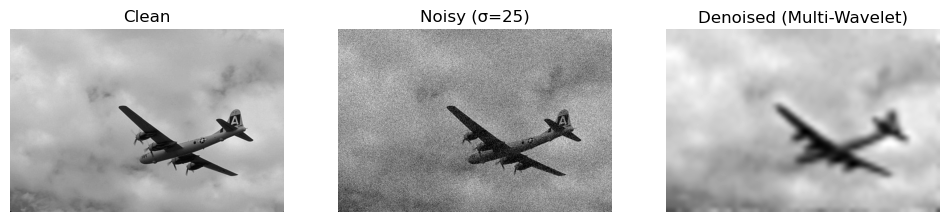

In [41]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(clean, cmap='gray')
plt.title("Clean")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(noisy, cmap='gray')
plt.title("Noisy (σ=25)")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(den, cmap='gray')
plt.title("Denoised (Multi-Wavelet)")
plt.axis('off')

plt.savefig("result.png")


In [38]:
def evaluate_dataset(clean_imgs, noisy_imgs, sigma, wavelets):
    psnr_list = []
    ssim_list = []

    for clean, noisy in tqdm(zip(clean_imgs, noisy_imgs), total=len(clean_imgs)):
        # run multi-wavelet POCS
        den = multi_wavelet_pocs(noisy, sigma, wavelets)

        # fix shape mismatch
        den = match_size(den, clean.shape)

        # compute metrics
        psnr, ssim = evaluate(clean, den)

        psnr_list.append(psnr)
        ssim_list.append(ssim)

    return psnr_list, ssim_list

# Run evaluation on full BSD68
sigma = 25
psnr_scores, ssim_scores = evaluate_dataset(clean_imgs, noisy_imgs, sigma, wavelets)

print("Average PSNR:", np.mean(psnr_scores))
print("Average SSIM:", np.mean(ssim_scores))

100%|██████████| 68/68 [00:08<00:00,  8.20it/s]

Average PSNR: 21.77105543203566
Average SSIM: 0.4987141526050421


In [42]:
NOISY15_DIR = os.path.join(BSD68_DIR, "noisy15")
NOISY50_DIR = os.path.join(BSD68_DIR, "noisy50")

noisy15_imgs, _ = load_images(NOISY15_DIR)
noisy50_imgs, _ = load_images(NOISY50_DIR)

# Evaluate sigma=15
sigma = 15
psnr15, ssim15 = evaluate_dataset(clean_imgs, noisy15_imgs, sigma, wavelets)
avg_psnr15 = np.mean(psnr15)
avg_ssim15 = np.mean(ssim15)
print("σ=15 → Avg PSNR:", avg_psnr15)
print("σ=15 → Avg SSIM:", avg_ssim15)

# Evaluate sigma=50
sigma = 50
psnr50, ssim50 = evaluate_dataset(clean_imgs, noisy50_imgs, sigma, wavelets)
avg_psnr50 = np.mean(psnr50)
avg_ssim50 = np.mean(ssim50)
print("σ=50 → Avg PSNR:", avg_psnr50)
print("σ=50 → Avg SSIM:", avg_ssim50)


100%|██████████| 68/68 [00:08<00:00,  7.83it/s]


σ=15 → Avg PSNR: 21.904190460415883
σ=15 → Avg SSIM: 0.5035127574646174


100%|██████████| 68/68 [00:08<00:00,  7.88it/s]

σ=50 → Avg PSNR: 21.35683102353672
σ=50 → Avg SSIM: 0.4851432934876386


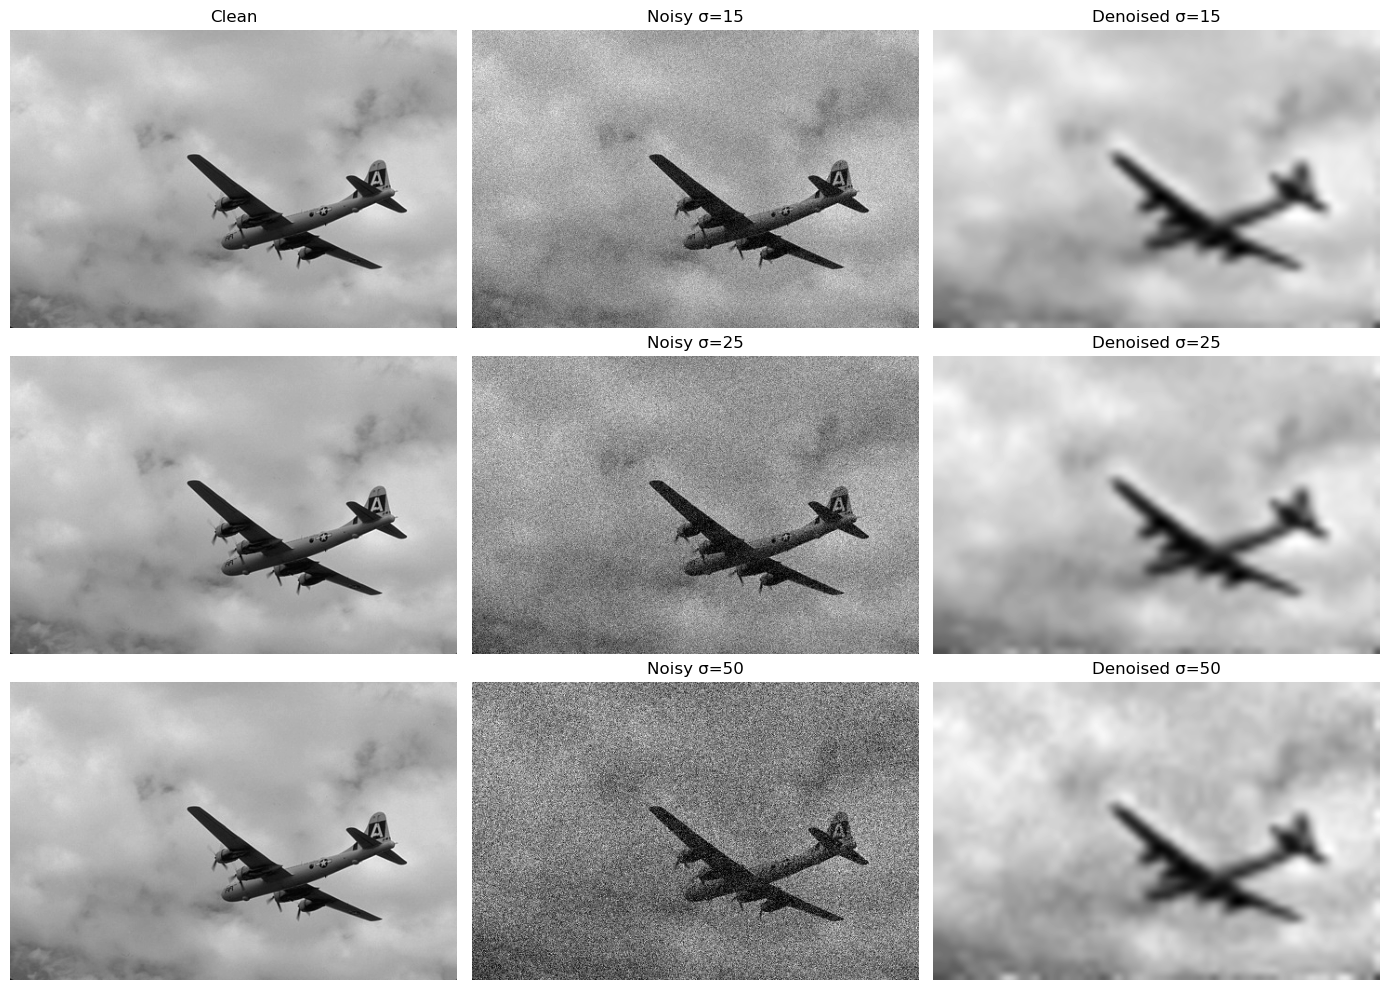

In [44]:
idx = 0  # same image for fair comparison
clean = clean_imgs[idx]

# Noisy images
noisy15 = noisy15_imgs[idx]
noisy25 = noisy_imgs[idx]
noisy50 = noisy50_imgs[idx]

den15 = multi_wavelet_pocs(noisy15, 15, wavelets)
den15 = match_size(den15, clean.shape)

den25 = multi_wavelet_pocs(noisy25, 25, wavelets)
den25 = match_size(den25, clean.shape)

den50 = multi_wavelet_pocs(noisy50, 50, wavelets)
den50 = match_size(den50, clean.shape)

plt.figure(figsize=(14,10))

plt.subplot(3,3,1); plt.imshow(clean, cmap='gray'); plt.title("Clean"); plt.axis('off')
plt.subplot(3,3,2); plt.imshow(noisy15, cmap='gray'); plt.title("Noisy σ=15"); plt.axis('off')
plt.subplot(3,3,3); plt.imshow(den15, cmap='gray'); plt.title("Denoised σ=15"); plt.axis('off')

plt.subplot(3,3,4); plt.imshow(clean, cmap='gray'); plt.axis('off')  # Duplicate for alignment
plt.subplot(3,3,5); plt.imshow(noisy25, cmap='gray'); plt.title("Noisy σ=25"); plt.axis('off')
plt.subplot(3,3,6); plt.imshow(den25, cmap='gray'); plt.title("Denoised σ=25"); plt.axis('off')

plt.subplot(3,3,7); plt.imshow(clean, cmap='gray'); plt.axis('off')
plt.subplot(3,3,8); plt.imshow(noisy50, cmap='gray'); plt.title("Noisy σ=50"); plt.axis('off')
plt.subplot(3,3,9); plt.imshow(den50, cmap='gray'); plt.title("Denoised σ=50"); plt.axis('off')

plt.tight_layout()
plt.savefig("result1.png")
